In [2]:
from PIL import Image
import numpy as np
from pathlib import Path

# --- load the image ---
img_path = Path("/Users/nairacampos/Desktop/MILK10k-Lesion-Classification/MILK10k-Lesion-Classification/data/milk10k/images/ISIC_0051817.jpg")

img = Image.open(img_path)
arr = np.array(img)

# --- compare PIL vs NumPy ordering ---
print("PIL img.size    (W, H):", img.size)
print("NumPy arr.shape (H, W, C):", arr.shape)

width, height = img.size
h, w, c = arr.shape

print(f"\nwidth={width}, height={height}  (from PIL)")
print(f"height={h}, width={w}, channels={c}  (from NumPy)")
assert (width, height) == (w, h)
print("\nConfirmed: same image, dimensions swapped between the two libraries.")

# --- demonstrate: pick a point (x, y) and access it correctly in both ---
x, y = 100, 50   # an arbitrary point: 100 px from the left, 50 px down

# PIL: getpixel takes (x, y) directly, matching image coordinates
pil_pixel = img.getpixel((x, y))
print(f"\nPIL img.getpixel((x={x}, y={y})) -> {pil_pixel}")

# NumPy: must index as [row, col] = [y, x] -- the order is swapped!
numpy_pixel = arr[y, x]
print(f"NumPy arr[y={y}, x={x}]           -> {numpy_pixel}")

# sanity check: both should return the same pixel value
assert tuple(numpy_pixel) == pil_pixel, "Mismatch -- indexing order is wrong!"
print("\nConfirmed: arr[y, x] in NumPy == img.getpixel((x, y)) in PIL")

# --- common mistake, shown explicitly ---
wrong_pixel = arr[x, y]  # swapped incorrectly
print(f"\nIncorrect: arr[x={x}, y={y}] (wrong order) -> {wrong_pixel}")
print("This only matches by coincidence if the image is square (H == W).")

PIL img.size    (W, H): (600, 450)
NumPy arr.shape (H, W, C): (450, 600, 3)

width=600, height=450  (from PIL)
height=450, width=600, channels=3  (from NumPy)

Confirmed: same image, dimensions swapped between the two libraries.

PIL img.getpixel((x=100, y=50)) -> (131, 104, 121)
NumPy arr[y=50, x=100]           -> [131 104 121]

Confirmed: arr[y, x] in NumPy == img.getpixel((x, y)) in PIL

Incorrect: arr[x=100, y=50] (wrong order) -> [138 120 136]
This only matches by coincidence if the image is square (H == W).


In [3]:
from pathlib import Path

project_root = Path.cwd().parent  # adjust if needed, e.g. .parent.parent
matches = list(project_root.rglob("ISIC_0051817.jpg"))
print(matches)

[PosixPath('/Users/nairacampos/Desktop/MILK10k-Lesion-Classification/MILK10k-Lesion-Classification/data/milk10k/images/ISIC_0051817.jpg')]


PIL img.size   (W, H): (600, 450)
NumPy arr.shape (H, W, C): (450, 600, 3)


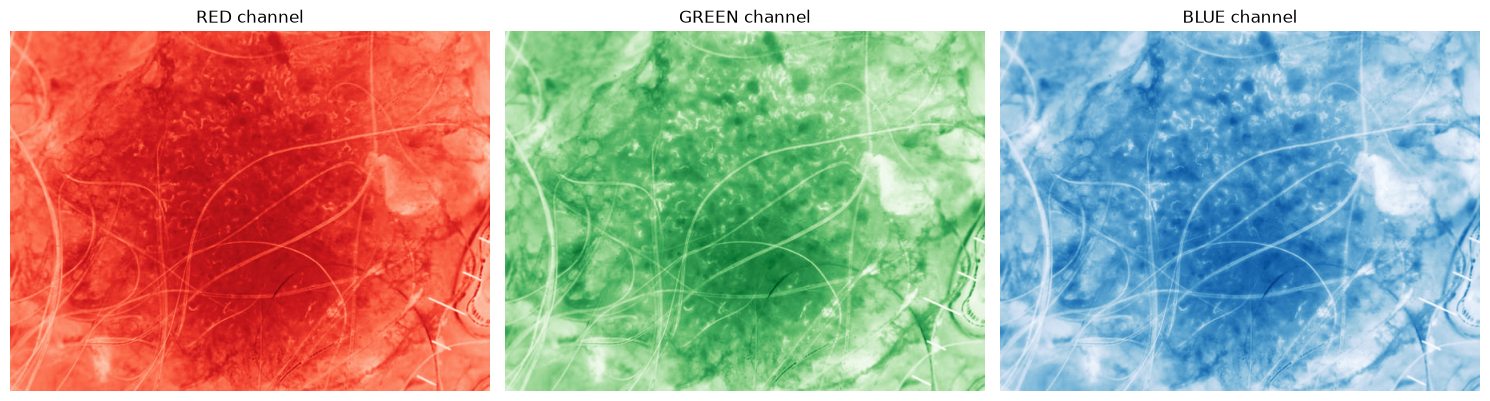

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

# --- load the image ---
img_path = Path("/Users/nairacampos/Desktop/MILK10k-Lesion-Classification/MILK10k-Lesion-Classification/data/milk10k/images/ISIC_0051817.jpg")

img = Image.open(img_path)
arr = np.array(img)

print("PIL img.size   (W, H):", img.size)
print("NumPy arr.shape (H, W, C):", arr.shape)

# --- split channels ---
red_channel   = arr[:, :, 0]
green_channel = arr[:, :, 1]
blue_channel  = arr[:, :, 2]

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(red_channel, cmap="Reds")
axes[0].set_title("RED channel")
axes[0].axis("off")

axes[1].imshow(green_channel, cmap="Greens")
axes[1].set_title("GREEN channel")
axes[1].axis("off")

axes[2].imshow(blue_channel, cmap="Blues")
axes[2].set_title("BLUE channel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Image shape (H, W, C): (450, 600, 3)

Mean intensity - RED:   133.99
Mean intensity - GREEN: 94.37
Mean intensity - BLUE:  109.63


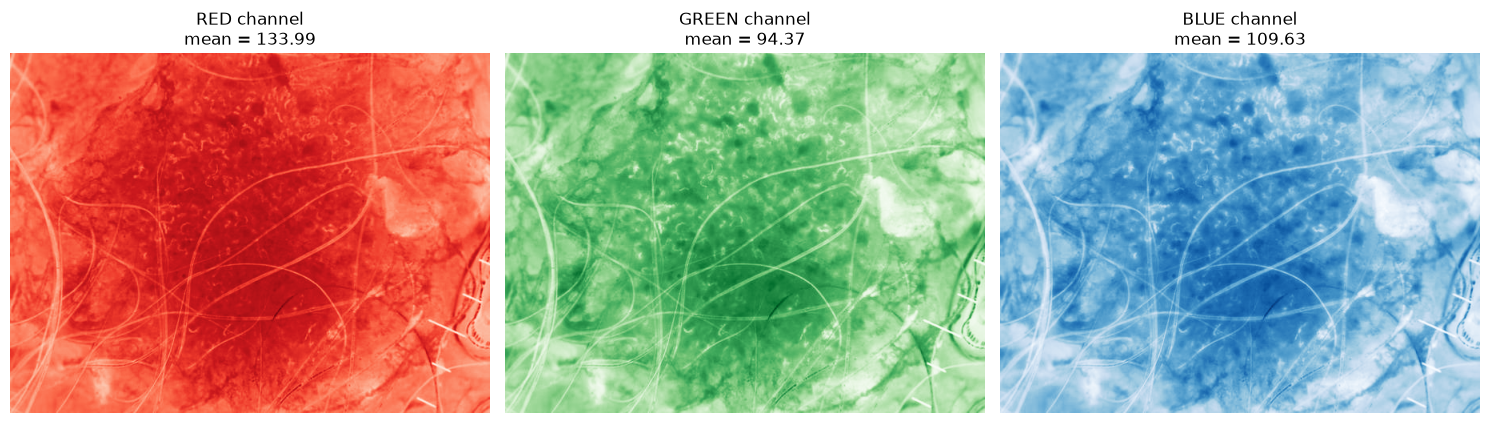

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

# --- load the image ---
img_path = Path("/Users/nairacampos/Desktop/MILK10k-Lesion-Classification/MILK10k-Lesion-Classification/data/milk10k/images/ISIC_0051817.jpg")

img = Image.open(img_path)
arr = np.array(img)

print("Image shape (H, W, C):", arr.shape)

# --- split channels ---
red_channel   = arr[:, :, 0]
green_channel = arr[:, :, 1]
blue_channel  = arr[:, :, 2]

# --- compute mean intensity of each channel ---
red_mean   = red_channel.mean()
green_mean = green_channel.mean()
blue_mean  = blue_channel.mean()

print(f"\nMean intensity - RED:   {red_mean:.2f}")
print(f"Mean intensity - GREEN: {green_mean:.2f}")
print(f"Mean intensity - BLUE:  {blue_mean:.2f}")

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(red_channel, cmap="Reds")
axes[0].set_title(f"RED channel\nmean = {red_mean:.2f}")
axes[0].axis("off")

axes[1].imshow(green_channel, cmap="Greens")
axes[1].set_title(f"GREEN channel\nmean = {green_mean:.2f}")
axes[1].axis("off")

axes[2].imshow(blue_channel, cmap="Blues")
axes[2].set_title(f"BLUE channel\nmean = {blue_mean:.2f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

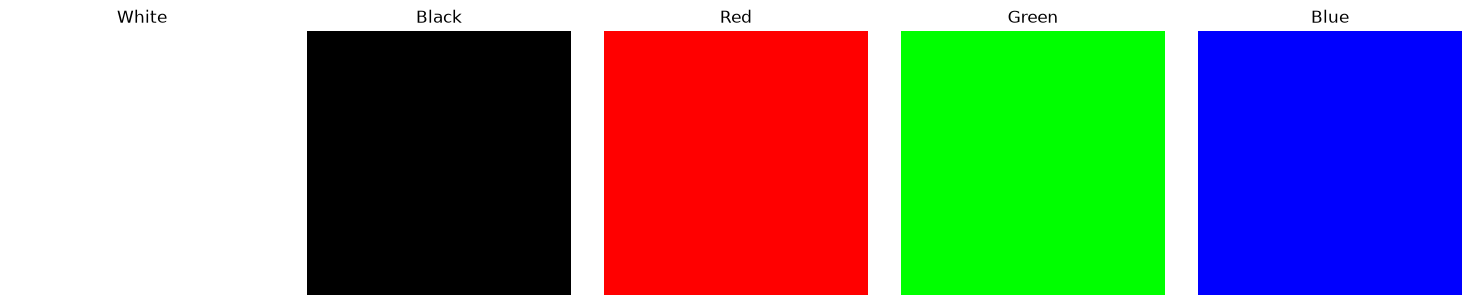

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# create 5x5 pixel images, each with 3 channels (RGB)
white_img = np.full((5, 5, 3), 255, dtype=np.uint8)
black_img = np.zeros((5, 5, 3), dtype=np.uint8)

red_img = np.zeros((5, 5, 3), dtype=np.uint8)
red_img[:, :, 0] = 255  # R channel maxed

green_img = np.zeros((5, 5, 3), dtype=np.uint8)
green_img[:, :, 1] = 255  # G channel maxed

blue_img = np.zeros((5, 5, 3), dtype=np.uint8)
blue_img[:, :, 2] = 255  # B channel maxed

images = [white_img, black_img, red_img, green_img, blue_img]
titles = ["White", "Black", "Red", "Green", "Blue"]

# --- plot ---
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

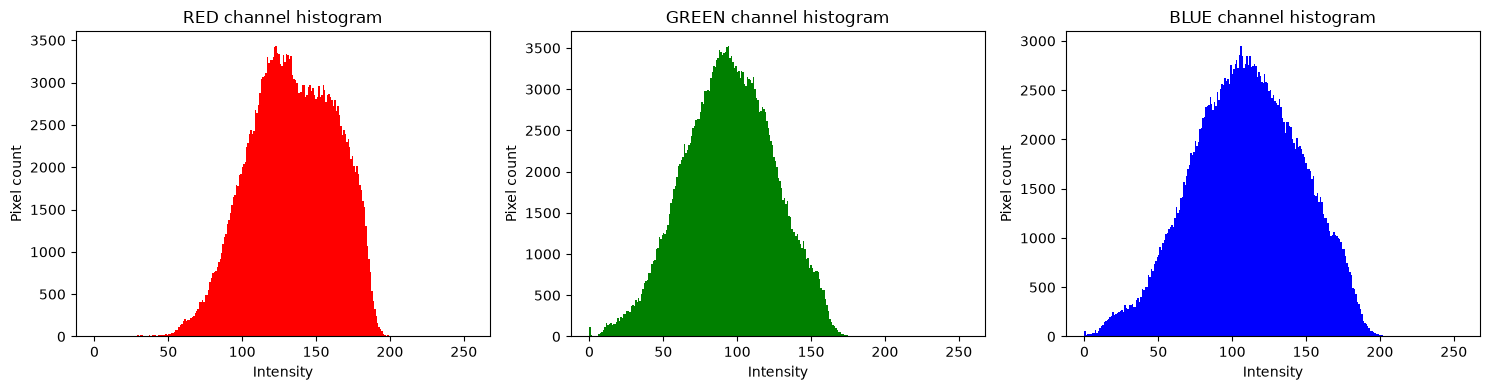

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

# --- load the image ---
img_path = Path("/Users/nairacampos/Desktop/MILK10k-Lesion-Classification/MILK10k-Lesion-Classification/data/milk10k/images/ISIC_0051817.jpg")

img = Image.open(img_path)
arr = np.array(img)

# --- split channels ---
red_channel   = arr[:, :, 0]
green_channel = arr[:, :, 1]
blue_channel  = arr[:, :, 2]

# --- plot histograms ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(red_channel.ravel(), bins=256, range=(0, 255), color="red")
axes[0].set_title("RED channel histogram")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Pixel count")

axes[1].hist(green_channel.ravel(), bins=256, range=(0, 255), color="green")
axes[1].set_title("GREEN channel histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Pixel count")

axes[2].hist(blue_channel.ravel(), bins=256, range=(0, 255), color="blue")
axes[2].set_title("BLUE channel histogram")
axes[2].set_xlabel("Intensity")
axes[2].set_ylabel("Pixel count")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
from PIL import Image
from pathlib import Path

# --- load the image ---
img_path = Path("/Users/nairacampos/Desktop/MILK10k-Lesion-Classification/MILK10k-Lesion-Classification/data/milk10k/images/ISIC_0051817.jpg")

img = Image.open(img_path)
arr = np.array(img)

# --- split channels ---
red_channel   = arr[:, :, 0]
green_channel = arr[:, :, 1]
blue_channel  = arr[:, :, 2]

# --- count pixels with intensity == 45, per channel ---
target = 45

red_count   = np.sum(red_channel == target)
green_count = np.sum(green_channel == target)
blue_count  = np.sum(blue_channel == target)

print(f"Pixels with intensity {target}:")
print(f"  RED:   {red_count}")
print(f"  GREEN: {green_count}")
print(f"  BLUE:  {blue_count}")

# --- if you want it across all channels combined (not per-channel) ---
total_count = np.sum(arr == target)
print(f"\nTotal across all channels combined: {total_count}")

Pixels with intensity 45:
  RED:   16
  GREEN: 1061
  BLUE:  688

Total across all channels combined: 1765


In [9]:
import numpy as np
from PIL import Image
from pathlib import Path

# --- load the image ---
img_path = Path("/Users/nairacampos/Desktop/MILK10k-Lesion-Classification/MILK10k-Lesion-Classification/data/milk10k/images/ISIC_0051817.jpg")

img = Image.open(img_path)
arr = np.array(img)

# --- split channels ---
red_channel   = arr[:, :, 0]
green_channel = arr[:, :, 1]
blue_channel  = arr[:, :, 2]

# --- compare mean intensity per channel ---
means = {
    "Red":   red_channel.mean(),
    "Green": green_channel.mean(),
    "Blue":  blue_channel.mean(),
}

for name, m in means.items():
    print(f"{name} channel mean intensity: {m:.2f}")

brightest_channel = max(means, key=means.get)
print(f"\nBrightest channel (highest mean intensity): {brightest_channel}")

Red channel mean intensity: 133.99
Green channel mean intensity: 94.37
Blue channel mean intensity: 109.63

Brightest channel (highest mean intensity): Red


arr shape: (450, 600, 3)
arr_gray shape: (450, 600)

arr[0,0] (RGB): [117  74  68]
arr_pixel00 gray value: 86.17299999999999
arr_gray[0,0]: 86


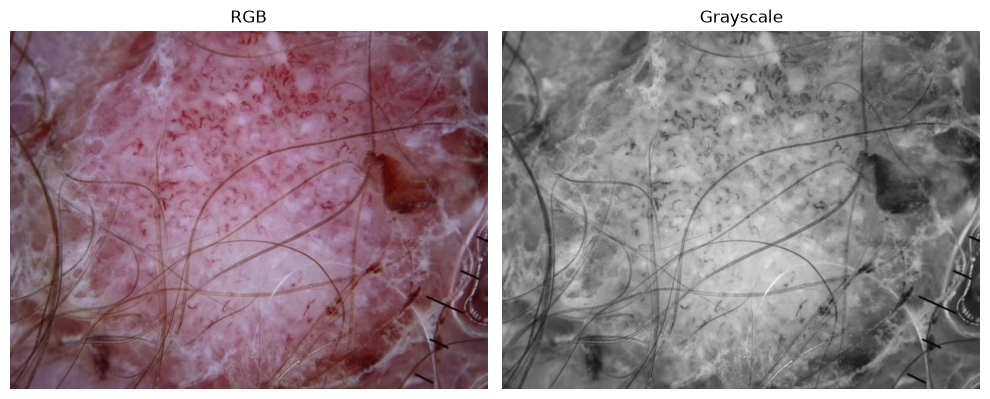

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Convert the image from RGB to Grayscale
# Gray = 0.299*R + 0.587*G + 0.114*B

arr_gray = 0.299*arr[:,:,0] + 0.587*arr[:,:,1] + 0.114*arr[:,:,2]
arr_gray = np.clip(arr_gray, 0, 255).astype(np.uint8)

print("arr shape:", arr.shape)
print("arr_gray shape:", arr_gray.shape)

# sanity check on a single pixel, same as before
arr_pixel00 = arr[0,0]
print("\narr[0,0] (RGB):", arr_pixel00)

arr_pixel00_gray = 0.299*arr[0,0,0] + 0.587*arr[0,0,1] + 0.114*arr[0,0,2]
print("arr_pixel00 gray value:", arr_pixel00_gray)
print("arr_gray[0,0]:", arr_gray[0,0])

# Plot 2 subplots RGB vs Grayscale
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(arr)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(arr_gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

plt.tight_layout()
plt.show()

[117  74  68]
86.17299999999999


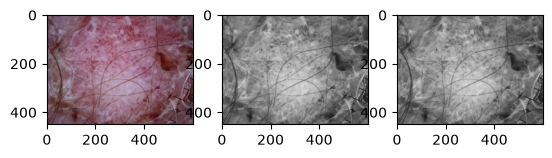

True

In [12]:
# Convert the image from RGB to Grayscale
# Gray = 0.299*R + 0.587*G + 0.114*B

arr_pixel00 = arr[0,0]
print(arr_pixel00)

arr_pixel00_gray = 0.299*arr[0,0,0] + 0.587*arr[0,0,1] + 0.114*arr[0,0,2]
print(arr_pixel00_gray)

#Plot 2 subplots RGB vs Grayscale
import cv2
arr_gray_cv2 = cv2.cvtColor(arr,cv2.COLOR_RGB2GRAY)

# manual way using the luminosity formula
arr_gray_manual = (0.299 * arr[:,:,0] + \
                    0.587 * arr[:,:,1] + \
                    0.114 * arr[:,:,2]).astype(np.uint8)

plt.subplot(1,3,1)
plt.imshow(arr)

plt.subplot(1,3,2)
plt.imshow(arr_gray_cv2,cmap='gray')

plt.subplot(1,3,3)
plt.imshow(arr_gray_manual,cmap='gray')

plt.show()

# using np.allclose
np.allclose(arr_gray_cv2, arr_gray_manual, atol=1)

In [1]:
import pandas as pd

df = pd.read_csv("metadata.csv")
print(df["lesion_id"].nunique())

FileNotFoundError: [Errno 2] No such file or directory: 'metadata.csv'